# Libraries

In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import string
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Loading Data

[Dataset Link](https://www.kaggle.com/datasets/studymart/welfake-dataset-for-fake-news)

In [70]:
df = pd.read_csv("WELFake_Dataset.csv", on_bad_lines='skip')
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [71]:
print(df.shape)

(72134, 4)


# EDA

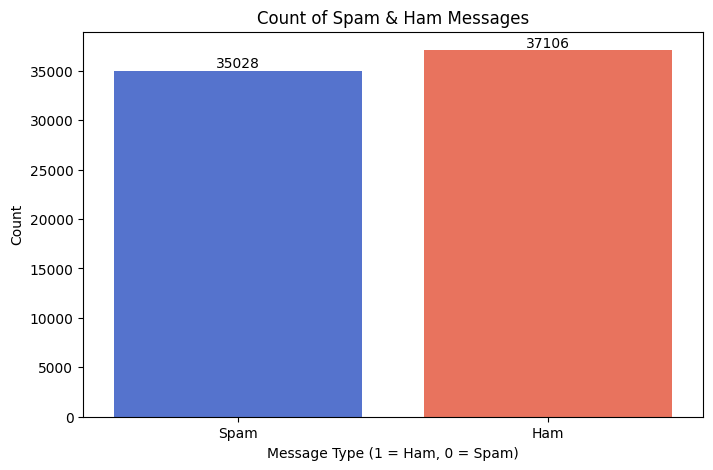

In [72]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=df['label'], palette=['royalblue', 'tomato'])
plt.xlabel("Message Type (1 = Ham, 0 = Spam)")
plt.ylabel("Count")
plt.title("Count of Spam & Ham Messages")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.xticks([0, 1], ["Spam", "Ham"])
plt.show()


In [73]:
label_Status = df['label'].value_counts()
transactions = label_Status.index
quantity = label_Status.values

figure = px.pie(
    df,
    values=quantity,
    names=transactions,
    hole=.60,
    title="Spam & Ham Status"
)
figure.show()

In [74]:
df['text'][0]

'No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called  Sunshine.  She has a radio blog show hosted from Texas called,  Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to  Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite   #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show, callers clearly call for  lynching  and  killing  of white people.A 2:39 minute clip from the radio show can be heard here. It was provided to Breitbart Texas by someone who would like to be referred to

In [75]:
df.tail()

,Unnamed: 0,title,text,label
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0
72133,72133,Goldman Sachs Endorses Hillary Clinton For Pre...,Goldman Sachs Endorses Hillary Clinton For Pre...,1


In [76]:
df['text'][72129]

'WASHINGTON (Reuters) - Hackers believed to be working for the Russian government broke into the Democratic National Committee’s computer network, spied on internal communications and accessed research on presumptive Republican presidential nominee Donald Trump, the committee and security experts said on Tuesday. Two separate groups entered the DNC’s system, and one read email and chat communications for nearly a year before being detected, according to the committee and CrowdStrike, the cyber firm that helped clean up the breach. Russian spies also targeted the networks of Trump and Democratic presidential candidate Hillary Clinton, as well as the computers of some Republican political action committees, the Washington Post quoted U.S. officials as saying, although details were not available. A Clinton campaign official said there was no evidence the campaign’s information systems had been hacked. A Russian government spokesman denied involvement in the breach. “I completely rule out 

In [77]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [78]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71576 non-null  object
 1   text    72095 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [79]:
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [80]:
df.fillna(' ', inplace=True)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   72134 non-null  object
 1   text    72134 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [82]:
features = df[['title', 'text']]
labels = df['label']

In [83]:
df.isnull().sum()

,0
title,0
text,0
label,0


In [84]:
df.shape

(72134, 3)

# Preprocessing...

In [85]:
def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

fake_text = ' '.join(df[df['label'] == 0]['text']) #fake
real_text = ' '.join(df[df['label'] == 1]['text']) #good


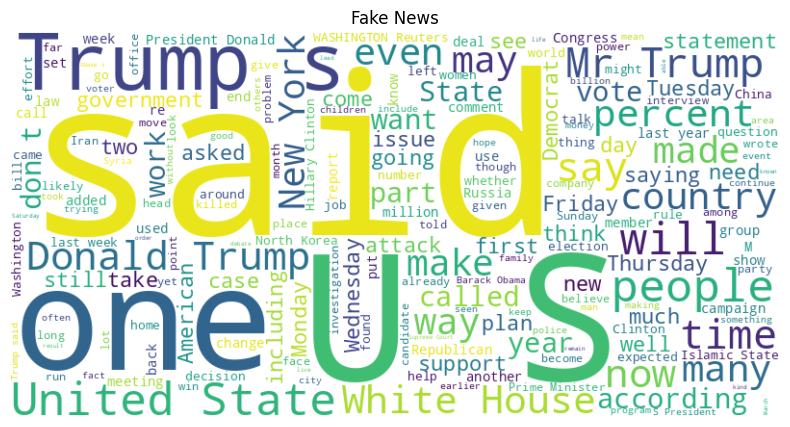

In [86]:
plot_wordcloud(fake_text, 'Fake News')

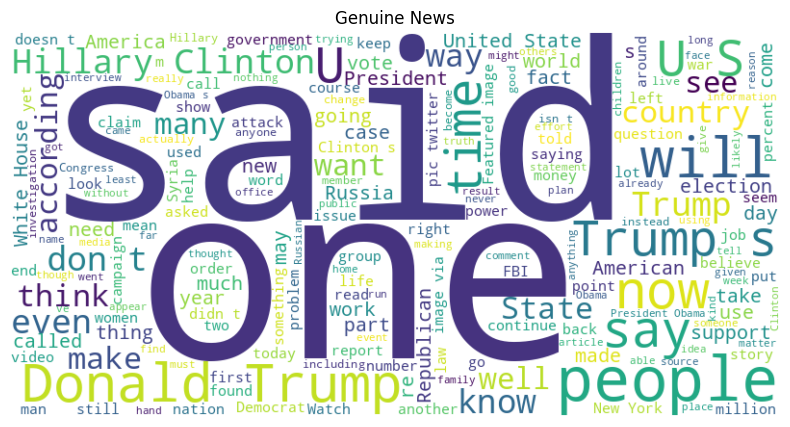

In [87]:
plot_wordcloud(real_text, 'Genuine News')

### remove punc and stopwords

In [88]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [89]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [90]:
stopwords.fileids()

['albanian',
 'arabic',
 'azerbaijani',
 'basque',
 'belarusian',
 'bengali',
 'catalan',
 'chinese',
 'danish',
 'dutch',
 'english',
 'finnish',
 'french',
 'german',
 'greek',
 'hebrew',
 'hinglish',
 'hungarian',
 'indonesian',
 'italian',
 'kazakh',
 'nepali',
 'norwegian',
 'portuguese',
 'romanian',
 'russian',
 'slovene',
 'spanish',
 'swedish',
 'tajik',
 'tamil',
 'turkish',
 'uzbek']

In [91]:
text_column = 'text'
label_column = 'label'

english_stopwords = set(stopwords.words('english'))
english_punctuation = string.punctuation

def preprocess_text(text):

    #remove punctuation
    remove_punc = [char for char in text if char not in english_punctuation]
    clean_text = ''.join(remove_punc)

    #remove stopwords
    words = clean_text.split()
    text = ' '.join([word for word in words if word.lower() not in english_stopwords])

    return text


In [92]:
df[text_column] = df[text_column].apply(preprocess_text)

In [93]:
df[text_column].head()

,text
0,comment expected Barack Obama Members FYF911 F...
1,post votes Hillary already
2,demonstrators gathered last night exercising c...
3,dozen politically active pastors came private ...
4,RS28 Sarmat missile dubbed Satan 2 replace SS1...


### Lemmatization for Text Normalization

In [94]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    lemmatized_text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

    return lemmatized_text

In [95]:
df[text_column] = df[text_column].apply(lemmatize_text)
df[text_column].head()

,text
0,comment expected Barack Obama Members FYF911 F...
1,post vote Hillary already
2,demonstrator gathered last night exercising co...
3,dozen politically active pastor came private d...
4,RS28 Sarmat missile dubbed Satan 2 replace SS1...


In [96]:
X_raw = df[text_column]
y = df[label_column]
labels = y

# Splitting to avoid data leakage

In [97]:
xtrain_raw, xtest_raw, ytrain, ytest = train_test_split(
    X_raw,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

In [98]:
xtrain_raw.shape

(50493,)

In [99]:
xtest_raw.shape

(21641,)

In [100]:
ytrain.shape

(50493,)

In [101]:
ytest.shape

(21641,)

# Text -> Vectorizer

In [102]:
vectorizer = TfidfVectorizer()

xtrain = vectorizer.fit_transform(xtrain_raw)   #fit ONLY on train
xtest = vectorizer.transform(xtest_raw) #only transform for test to avoid data leakage

In [103]:
x = xtrain

In [104]:
xtrain.shape

(50493, 301353)

In [105]:
xtest.shape

(21641, 301353)

# Evaluation Functions

In [106]:
def evaluate_model(model, xtest, ytest):
    y_pred = model.predict(xtest)
    accuracy = accuracy_score(ytest, y_pred)
    cm = confusion_matrix(ytest, y_pred)
    return {
        'Accuracy': accuracy,
        'Confusion Matrix': cm
    }

In [107]:
def plot_confusion(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# ----- Multinomial Naive Bayes ----

MultinomialNB: {'Accuracy': 0.8716325493276651, 'Confusion Matrix': array([[9600,  909],
       [1869, 9263]])}


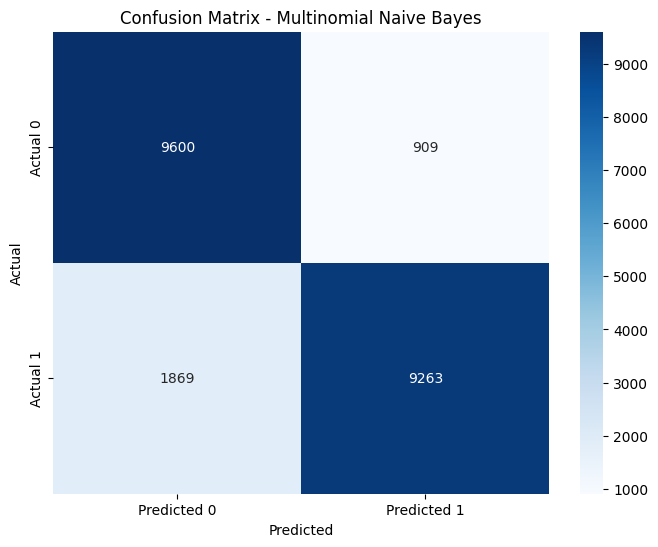

In [108]:
mnb_model = MultinomialNB()
mnb_model.fit(xtrain, ytrain)

mnb_results = evaluate_model(mnb_model, xtest, ytest)
print("MultinomialNB:", mnb_results)

cm_mnb = mnb_results['Confusion Matrix']
plot_confusion(cm_mnb, 'Confusion Matrix - Multinomial Naive Bayes')

# Classification Report

In [109]:
print("Classification Report - Multinomial Naive Bayes")
print(classification_report(ytest, mnb_model.predict(xtest), digits=3))

Classification Report - Multinomial Naive Bayes
              precision    recall  f1-score   support

           0      0.837     0.914     0.874     10509
           1      0.911     0.832     0.870     11132

    accuracy                          0.872     21641
   macro avg      0.874     0.873     0.872     21641
weighted avg      0.875     0.872     0.872     21641



# AUC and ROC Curve

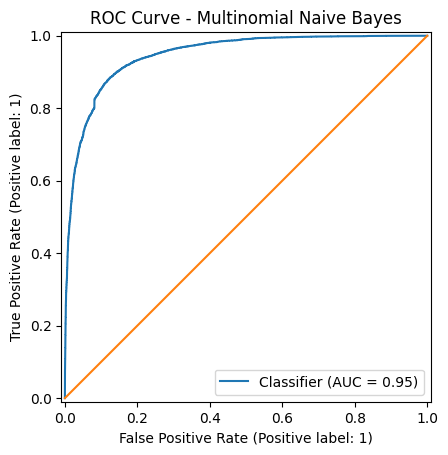

In [110]:
mnb_proba = mnb_model.predict_proba(xtest)[:, 1]
RocCurveDisplay.from_predictions(ytest, mnb_proba)
plt.plot([0,1],[0,1]) #center line er jonno
plt.title("ROC Curve - Multinomial Naive Bayes")
plt.show()

# ------------ Bernoulli Naive Bayes ------------

BernoulliNB: {'Accuracy': 0.8442770666789889, 'Confusion Matrix': array([[8369, 2140],
       [1230, 9902]])}


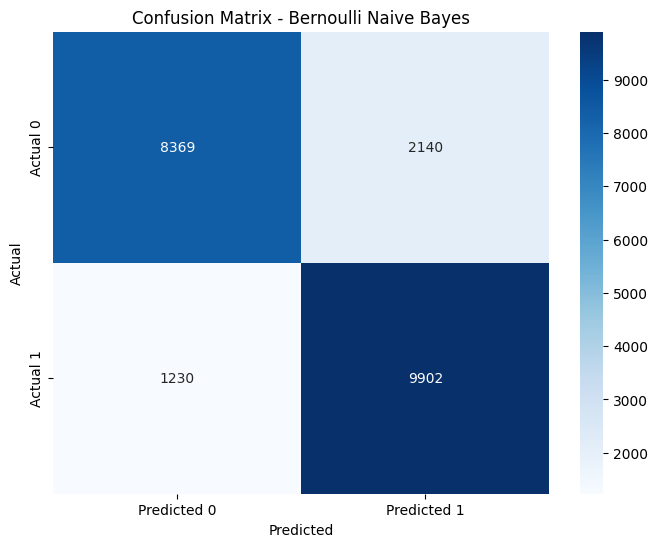

In [111]:
bnb_model = BernoulliNB()
bnb_model.fit(xtrain, ytrain)

bnb_results = evaluate_model(bnb_model, xtest, ytest)
print("BernoulliNB:", bnb_results)

cm_bnb = bnb_results['Confusion Matrix']
plot_confusion(cm_bnb, 'Confusion Matrix - Bernoulli Naive Bayes')


In [112]:
print("Classification Report - Bernoulli Naive Bayes")
print(classification_report(ytest, bnb_model.predict(xtest), digits=3))

Classification Report - Bernoulli Naive Bayes
              precision    recall  f1-score   support

           0      0.872     0.796     0.832     10509
           1      0.822     0.890     0.855     11132

    accuracy                          0.844     21641
   macro avg      0.847     0.843     0.843     21641
weighted avg      0.846     0.844     0.844     21641



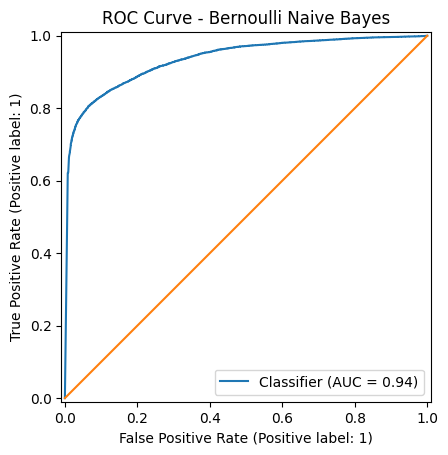

In [113]:
bnb_proba = bnb_model.predict_proba(xtest)[:, 1]
RocCurveDisplay.from_predictions(ytest, bnb_proba)
plt.plot([0,1],[0,1])
plt.title("ROC Curve - Bernoulli Naive Bayes")
plt.show()

# Logistic Regression

Logistic Regression: {'Accuracy': 0.9506954392126057, 'Confusion Matrix': array([[ 9884,   625],
       [  442, 10690]])}


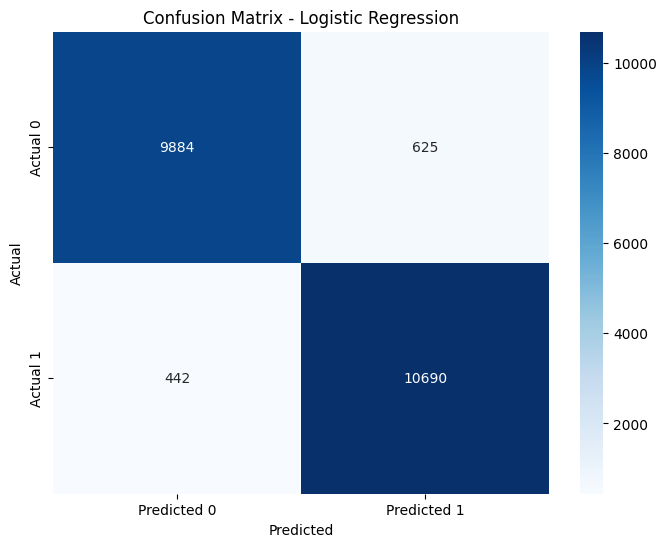

In [114]:
lr_model = LogisticRegression(max_iter=10000, penalty='l2')
lr_model.fit(xtrain, ytrain)

lr_results = evaluate_model(lr_model, xtest, ytest)
print("Logistic Regression:", lr_results)

cm_lr = lr_results['Confusion Matrix']
plot_confusion(cm_lr, 'Confusion Matrix - Logistic Regression')


In [115]:
print("Classification Report - Logistic Regression")
print(classification_report(ytest, lr_model.predict(xtest), digits=3))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0      0.957     0.941     0.949     10509
           1      0.945     0.960     0.952     11132

    accuracy                          0.951     21641
   macro avg      0.951     0.950     0.951     21641
weighted avg      0.951     0.951     0.951     21641



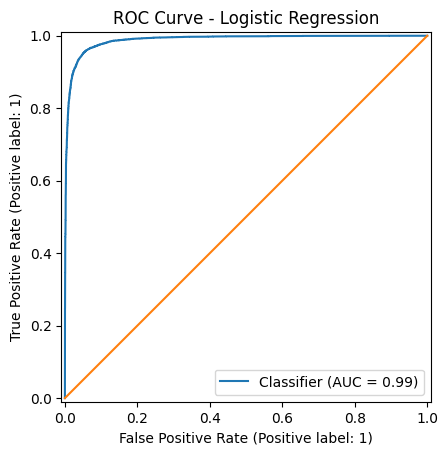

In [116]:
lr_proba = lr_model.predict_proba(xtest)[:, 1]
RocCurveDisplay.from_predictions(ytest, lr_proba)
plt.plot([0,1],[0,1])
plt.title("ROC Curve - Logistic Regression")
plt.show()

# Evaluation alltogether

In [117]:
def plot_histogram(metric_values, model_names, metric_name):

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(model_names, metric_values)
    plt.xlabel('Models')
    plt.ylabel(metric_name)
    plt.title(f'{metric_name} for Different Models')

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval,
                round(yval, 3),
                ha='center',
                va='bottom',
                color='black')
    plt.show()

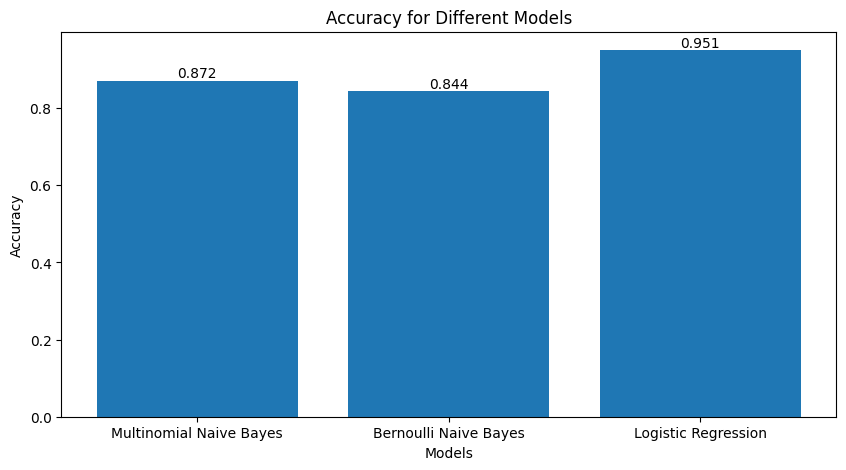

In [118]:
accuracy_values = [
    mnb_results['Accuracy'],
    bnb_results['Accuracy'],
    lr_results['Accuracy']
]
model_names = ['Multinomial Naive Bayes', 'Bernoulli Naive Bayes', 'Logistic Regression']

plot_histogram(accuracy_values, model_names, 'Accuracy')

# Inference: Input random text and make a prediction

In [119]:
models = [mnb_model, bnb_model, lr_model]  #objects for ml models

def predict_for_text(random_text):

    #same preprocessing pipeline
    preprocessed_text = preprocess_text(random_text)
    lemmatized_text = lemmatize_text(preprocessed_text)
    text_vector = vectorizer.transform([lemmatized_text])

    #print("Preprocessed text:", preprocessed_text)
    #print("Lemmatized text:", lemmatized_text)
    print("Vector shape:", text_vector.shape)

    for model in models:
        prediction = model.predict(text_vector)

        print(f"\nModel Name: {type(model).__name__}")
        print("Prediction:", prediction[0])


In [120]:
text = 'WASHINGTON (Reuters) - Hackers believed to be working for the Russian government broke into the Democratic National Committee’s computer network, spied on internal communications and accessed research on presumptive Republican presidential nominee Donald Trump, the committee and security experts said on Tuesday. Two separate groups entered the DNC’s system, and one read email and chat communications for nearly a year before being detected, according to the committee and CrowdStrike, the cyber firm that helped clean up the breach. Russian spies also targeted the networks of Trump and Democratic presidential candidate Hillary Clinton, as well as the computers of some Republican political action committees, the Washington Post quoted U.S. officials as saying, although details were not available. A Clinton campaign official said there was no evidence the campaign’s information systems had been hacked. A Russian government spokesman denied involvement in the breach. “I completely rule out a possibility that the (Russian) government or the government bodies have been involved in this,” Dmitry Peskov, a Kremlin spokesman, told Reuters in Moscow. The intrusion is emblematic of the sophistication of Russian hackers, who intelligence officials have long viewed as the most talented of U.S. adversaries in cyberspace. The Democratic Party had been aware of efforts to hack Trump material for two months, and U.S. intelligence agencies were involved in efforts to find out who was behind the hacking, a source familiar with Trump opposition research said. The source said Democratic Party operatives believed the hacking was conducted by the Russian government. The research includes material on Trump’s business efforts in Azerbaijan, Georgia, Serbia and Russia, according to information made available to Reuters.         Cyber attacks against political candidates and organizations are common worldwide. U.S. National Intelligence Director James Clapper said last month he was aware of attempted hacks on campaigns and related groups and he expected to see more as the Nov. 8 presidential election nears. U.S. Representative Jim Langevin, a Democrat and co-founder of the congressional cybersecurity caucus, said it was “disconcerting” that independent groups penetrated the DNC and that one was able “to stay embedded for nearly a year.” But the groups are extremely sophisticated, Langevin said, and have previously been implicated on attacks at the White House, the State Department and the German Bundestag, as well as a number of private companies. The DNC contacted CrowdStrike in May and within 24 hours it began investigating unusual activity on the group’s network, said Dmitri Alperovitch, the company’s co-founder and chief technology officer. It identified two hacking groups and both were kicked out this weekend, he said. The first, which CrowdStrike named Cozy Bear, entered the DNC’s systems last summer, according to the firm. It primarily monitored email and chat conversations and may be working for Russia’s Federal Security Service, or FSB, Alperovitch said.  Russian President Vladimir Putin once ran the FSB. The second group, nicknamed Fancy Bear, is probably working on behalf of Russia’s military, Alperovitch said. It gained entry in late April and “went straight to the oppo research ... on Donald Trump and exfiltrated some of it,” he said. Alperovitch said both groups were among “the best threat actors that we’ve ever encountered” but they did not appear to be working together. He was not sure how the intrusions occurred but suspected the hackers may have leveraged “spearphishing” emails to trick DNC employees into downloading malicious code onto their network. “When we discovered the intrusion, we treated this like the serious incident it is,” Rep. Debbie Wasserman Schultz, chairwoman of the DNC, said in a statement. “Our team moved as quickly as possible to kick out the intruders and secure our network.” Trump’s interest in Russia goes back to the 1980s, with a 1990 Vanity Fair article citing news program appearances in which Trump offered his own services as a negotiator with Russia.  Information made available to Reuters indicates Trump tried on at least three occasions - in 2004, 2008 and 2013 - to get involved in business deals in Russia. In 2013, he and an Azerbaijani-Russian oligarch, Aras Agalarov, jointly put on a Miss Universe competition in Moscow, and Trump was photographed with Agalarov’s wife, son and daughter. The last two U.S. presidential cycles in 2008 and 2012 witnessed a barrage of cyber attacks from a range of adversaries targeting President Barack Obama’s campaign and the campaigns of his Republican foes. U.S. intelligence officials have said many previous assaults were linked to Chinese hackers. '

In [121]:
text

'WASHINGTON (Reuters) - Hackers believed to be working for the Russian government broke into the Democratic National Committee’s computer network, spied on internal communications and accessed research on presumptive Republican presidential nominee Donald Trump, the committee and security experts said on Tuesday. Two separate groups entered the DNC’s system, and one read email and chat communications for nearly a year before being detected, according to the committee and CrowdStrike, the cyber firm that helped clean up the breach. Russian spies also targeted the networks of Trump and Democratic presidential candidate Hillary Clinton, as well as the computers of some Republican political action committees, the Washington Post quoted U.S. officials as saying, although details were not available. A Clinton campaign official said there was no evidence the campaign’s information systems had been hacked. A Russian government spokesman denied involvement in the breach. “I completely rule out 

In [122]:
predict_for_text(text)

Vector shape: (1, 301353)

Model Name: MultinomialNB
Prediction: 0

Model Name: BernoulliNB
Prediction: 0

Model Name: LogisticRegression
Prediction: 0


# Save

In [123]:
import pickle

model_file_path = "logistic_regression_tfidf.pkl"

with open(model_file_path, "wb") as model_file:
    pickle.dump(
        {
            "model": lr_model,       #trained LogisticRegression
            "vectorizer": vectorizer #fitted TfidfVectorizer
        },
        model_file
    )

print(f"Saved Logistic Regression model and vectorizer to: {model_file_path}")


Saved Logistic Regression model and vectorizer to: logistic_regression_tfidf.pkl


# Load

In [124]:
with open(model_file_path, "rb") as model_file:
    saved_objects = pickle.load(model_file)

loaded_LR = saved_objects["model"]
loaded_vectorizer = saved_objects["vectorizer"]

print(type(loaded_LR), "loaded successfully")
print(type(loaded_vectorizer), "loaded successfully")

<class 'sklearn.linear_model._logistic.LogisticRegression'> loaded successfully
<class 'sklearn.feature_extraction.text.TfidfVectorizer'> loaded successfully


# Input → preprocessing → TF-IDF → model → prediction.

In [125]:
def predict_for_text(random_text):

    # same preprocessing pipeline as training
    preprocessed_text = preprocess_text(random_text)
    lemmatized_text = lemmatize_text(preprocessed_text)
    text_vector = loaded_vectorizer.transform([lemmatized_text])

    #print("Vector shape:", text_vector.shape)

    prediction = loaded_LR.predict(text_vector)[0]

    prediction_proba = None
    if hasattr(loaded_LR, "predict_proba"): #hasattr(obj, "predict_proba")
        prediction_proba = loaded_LR.predict_proba(text_vector)[0, 1]  #value of 1st row, 2nd col -> [probability_of_class_0, probability_of_class_1]

    print("\nModel Name: LogisticRegression")
    print("Prediction:", prediction)

    if prediction_proba is not None:
        print("Probability of class 1:", round(prediction_proba, 4))

    return prediction, prediction_proba

In [126]:
predict_for_text(text)


Model Name: LogisticRegression
Prediction: 0
Probability of class 1: 0.0052


(np.int64(0), np.float64(0.0052316079407887075))